# **Tarea 4:** Single Neuron
Universidad de Monterrey  
**Curso**: Inteligencia Artificial II  
**Estudiantes**: Antonio Rivera Aguirre y Jerónimo Alvarez Lozano  
**Profesor**: Dr. Andrés Hernández Gutiérrez  
**Fecha**: 6 de marzo de 2026  
**Lugar**: San Pedro Garza García, Nuevo León  

# **Importación de librerías**

**Explicación:** Importamos las librerías necesarias para la tarea, incluyendo aquellas que se usan para graficar y para el entrenamiento del modelo neuronal.

In [328]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import plotly.express as px
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#**1. Introduction to the real-world problem:**

# **Importación de datos:**

**Explicación:** Este dataset de clasificación es del área médica, listando diferentes índices de concentración de vitaminas en el sistema sanguíneo de una muestra de personas. El propósito del modelo de clasificación es predecir si una persona presenta problemas de deficiencia vitamínica con base en características de salud como hábitos, síntomas, consumo, entre otras. En la primera tabla podemos observar que ciertos valores aparecen como `NaN`, ya que el dataset guarda ciertos valores como `None`, específicamente aquellas personas que no consumen alcohol. En este caso, la importación del dataset detecta estos `None` como celdas vacías.

Las variables a considerar son las siguientes:
- `age`: Edad del paciente (años).
- `gender`: Género del paciente.
- `bmi`: Índice de masa corporal (IMC).
- `smoking_status`: Estado de fumador.
- `alcohol_consumption`: Nivel de consumo de alcohol.
- `exercise_level`: Nivel de actividad física habitual.
- `diet_type`: Tipo de dieta.
- `sun_exposure`: Nivel de exposición solar.
- `income_level`: Nivel socioeconómico.
- `latitude_region`: Región geográfica según latitud.

- `vitamin_a_percent_rda`: Porcentaje de ingesta diaria recomendada de vitamina A.
- `vitamin_c_percent_rda`: Porcentaje de ingesta diaria recomendada de vitamina C.
- `vitamin_d_percent_rda`: Porcentaje de ingesta diaria recomendada de vitamina D.
- `vitamin_e_percent_rda`: Porcentaje de ingesta diaria recomendada de vitamina E.
- `vitamin_b12_percent_rda`: Porcentaje de ingesta diaria recomendada de vitamina B12.
- `folate_percent_rda`: Porcentaje de ingesta diaria recomendada de folato ( vitamina B9).
- `calcium_percent_rda`: Porcentaje de ingesta diaria recomendada de calcio.
- `iron_percent_rda`: Porcentaje de ingesta diaria recomendada de hierro.

- `hemoglobin_g_dl`: Nivel de hemoglobina en la sangre (g/dL).
- `serum_vitamin_d_ng_ml`: Nivel de vitamina D en la sangre (ng/mL).
- `serum_vitamin_b12_pg_ml`: Nivel de vitamina B12 en la sangre (pg/mL).
- `serum_folate_ng_ml`: Nivel de folato en la sangre (ng/mL).

- `symptoms_count`: Número total de síntomas reportados.
- `symptoms_list`: Lista de síntomas presentes.
- `has_night_blindness`: Indica presencia de ceguera nocturna.
- `has_fatigue`: Indica presencia de fatiga.
- `has_bleeding_gums`: Indica presencia de sangrado de encías.
- `has_bone_pain`: Indica presencia de dolor óseo.
- `has_muscle_weakness`: Indica presencia de debilidad muscular.
- `has_numbness_tingling`: Indica presencia de entumecimiento u hormigueo.
- `has_memory_problems`: Indica presencia de problemas de memoria.
- `has_pale_skin`: Indica presencia de palidez cutánea.

- `disease_diagnosis`: Diagnóstico clínico asociado a deficiencia nutricional. (TARGET)
- `has_multiple_deficiencies`: Indica si presenta múltiples deficiencias vitamínicas.

In [329]:
df = pd.read_csv('/content/vitamin_deficiency_disease_dataset_20260123.csv')
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0


# **Limpieza de datos:**

**Explicación:**
Se revisa la información del dataset para ver que no hay valores nulos. Como se muestra en la tabla, hay valores nulos en las columnas de `alcohol_consumption` y `symptoms_list`. En el caso de `alcohol_consumption` ocurre debido a la conversión de las celdas con `None` a valor nulo, por lo que se requiere rellenar estas celdas con su valor original. En el caso de `symptoms_list`, las celdas vacías muestran que la persona no tiene ningún síntoma de los listados. Al estar desarrollando un modelo de clasificación binario, esta distinción no es necesaria, solo definir si la persona cuenta con deficiencia vitamínica o no, por lo que esta columna será eliminada más adelante.


In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4000 non-null   int64  
 1   gender                     4000 non-null   object 
 2   bmi                        4000 non-null   float64
 3   smoking_status             4000 non-null   object 
 4   alcohol_consumption        2722 non-null   object 
 5   exercise_level             4000 non-null   object 
 6   diet_type                  4000 non-null   object 
 7   sun_exposure               4000 non-null   object 
 8   income_level               4000 non-null   object 
 9   latitude_region            4000 non-null   object 
 10  vitamin_a_percent_rda      4000 non-null   float64
 11  vitamin_c_percent_rda      4000 non-null   float64
 12  vitamin_d_percent_rda      4000 non-null   float64
 13  vitamin_e_percent_rda      4000 non-null   float

**Explicación:** Para poder utilizar la columna `disease_diagnosis` como nuestro target binario, optamos por convertirlo para que en lugar de predecir el tipo de enfermedad que se tiene, predecir si la persona tiene una deficiencia vitamínica o no. Para esto, los datos de la columna se mapearon para que `Healthy` se iguale a 0, mientras que el resto de diagnósticos sea igual a 1.

In [331]:
df["disease_diagnosis"] = df["disease_diagnosis"].map({"Healthy": 0,
                                                       "Anemia": 1,
                                                       "Rickets_Osteomalacia": 1,
                                                       "Night_Blindness": 1,
                                                       "Scurvy": 1})
target = df["disease_diagnosis"]

**Explicación:** Se decidió borrar aquellas columnas que identifican las enfermedades, ya que con el propósito que le vamos a dar al dataset, la información que tienen es redundante para nuestra variable objetivo.

In [332]:
df = df.drop(columns=["symptoms_count",
                      "symptoms_list",
                      "has_multiple_deficiencies"])

**Explicación:** En el dataset, los no consumidores se guardan como `None`, pero al importar el dataset a un dataFrame, se pierde este valor, leyéndolo como celda vacía, por lo que se debe reescribir el valor original.

In [333]:
df["alcohol_consumption"] = df["alcohol_consumption"].fillna("None")
df["alcohol_consumption"].value_counts()

,count
alcohol_consumption,
Moderate,1372
Heavy,1350
None,1278


**Explicación:** Se mapearon diferentes variables categóricas para convertirlas a numéricas. `gender` identifica si la persona es mujer o no. `smoking_status`, `alcohol_consumption`, `exercise_level`, `sun_exposure` e `income_level` da un valor con mayor prioridad a aquellos que practican más o experimentan más  seguido lo que identifica la categoría.

In [334]:
df["gender"] = df["gender"].map({"Male": 0, "Female": 1})
df["smoking_status"] = df["smoking_status"].map({"Never": 0, "Former": 1, "Current": 2})
df["alcohol_consumption"] = df["alcohol_consumption"].map({"None": 0, "Moderate": 1, "Heavy": 2})
df["exercise_level"] = df["exercise_level"].map({"Sedentary": 0, "Light": 1, "Moderate":2, "Active": 3})
df["sun_exposure"] = df["sun_exposure"].map({"Low": 0, "Moderate": 1, "High": 2})
df["income_level"] = df["income_level"].map({"Low": 0, "Middle": 1, "High": 2})
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,serum_folate_ng_ml,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis
0,79,0,24.8,1,0,3,Vegetarian,2,2,Mid,...,23.3,0,0,0,0,0,0,0,0,0
1,77,1,39.9,1,1,1,Omnivore,0,0,Low,...,5.3,0,0,0,1,0,0,0,0,1
2,24,0,26.4,1,2,2,Omnivore,0,2,High,...,16.3,1,0,0,0,0,0,0,0,0
3,69,0,23.1,0,2,2,Vegetarian,2,0,Low,...,9.2,0,0,0,0,0,1,1,0,1
4,63,0,29.6,0,0,2,Vegetarian,1,2,Low,...,13.4,0,0,0,0,0,0,0,0,0


**Explicación:** Revisamos los tipos de dieta que identifica el dataset para validar si es viable o no convertir esta columna y hacer uso de dummies.

In [335]:
df["diet_type"].value_counts()

,count
diet_type,
Vegan,1017
Vegetarian,999
Omnivore,993
Pescatarian,991


**Explicación:** Al tener 4 tipos de dieta en el dataset, vemos viable hacer dummies y eliminar la columna `diet_type_Pescatarian` para evitar redundancia.

In [336]:
df = pd.get_dummies(df, columns=["diet_type"], dtype=int)
df = df.drop(columns=["diet_type_Pescatarian"])
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,...,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,diet_type_Omnivore,diet_type_Vegan,diet_type_Vegetarian
0,79,0,24.8,1,0,3,2,2,Mid,119.1,...,0,0,0,0,0,0,0,0,0,1
1,77,1,39.9,1,1,1,0,0,Low,85.7,...,0,1,0,0,0,0,1,1,0,0
2,24,0,26.4,1,2,2,0,2,High,48.3,...,0,0,0,0,0,0,0,1,0,0
3,69,0,23.1,0,2,2,2,0,Low,75.8,...,0,0,0,1,1,0,1,0,0,1
4,63,0,29.6,0,0,2,1,2,Low,93.3,...,0,0,0,0,0,0,0,0,0,1


**Explicación:** Revisamos las regiones por latitud para validar si es viable o no convertir esta columna y hacer uso de dummies.

In [337]:
df["latitude_region"].value_counts()

,count
latitude_region,
Low,1358
High,1350
Mid,1292


**Explicación:** Al tener 3 latitudes en el dataset, vemos viable hacer dummies y eliminar la columna `latitude_region_Mid` para evitar redundancia.

In [338]:
df = pd.get_dummies(df, columns=["latitude_region"], dtype=int)
df = df.drop(columns=["latitude_region_Mid"])
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,vitamin_a_percent_rda,vitamin_c_percent_rda,...,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,diet_type_Omnivore,diet_type_Vegan,diet_type_Vegetarian,latitude_region_High,latitude_region_Low
0,79,0,24.8,1,0,3,2,2,119.1,147.3,...,0,0,0,0,0,0,0,1,0,0
1,77,1,39.9,1,1,1,0,0,85.7,57.5,...,0,0,0,0,1,1,0,0,0,1
2,24,0,26.4,1,2,2,0,2,48.3,152.1,...,0,0,0,0,0,1,0,0,1,0
3,69,0,23.1,0,2,2,2,0,75.8,51.0,...,0,1,1,0,1,0,0,1,0,1
4,63,0,29.6,0,0,2,1,2,93.3,111.5,...,0,0,0,0,0,0,0,1,0,1


**Explicación:** Movemos el target dentro del dataset, haciendo que este vuelva al final de la tabla, con el fin de hacer la lectura de tablas como la tabla de correlación más sencilla.

In [339]:
df = df.drop(columns=["disease_diagnosis"])
df["disease_diagnosis"] = target
df.head()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,vitamin_a_percent_rda,vitamin_c_percent_rda,...,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,diet_type_Omnivore,diet_type_Vegan,diet_type_Vegetarian,latitude_region_High,latitude_region_Low,disease_diagnosis
0,79,0,24.8,1,0,3,2,2,119.1,147.3,...,0,0,0,0,0,0,1,0,0,0
1,77,1,39.9,1,1,1,0,0,85.7,57.5,...,0,0,0,0,1,0,0,0,1,1
2,24,0,26.4,1,2,2,0,2,48.3,152.1,...,0,0,0,0,1,0,0,1,0,0
3,69,0,23.1,0,2,2,2,0,75.8,51.0,...,0,1,1,0,0,0,1,0,1,1
4,63,0,29.6,0,0,2,1,2,93.3,111.5,...,0,0,0,0,0,0,1,0,1,0


# **Análisis exploratorio de datos:**

**Explicación:** Exploramos la información del dataset para ver qué contienen las variables. Se puede observar que todos los valores son numéricos y que existen diferentes rangos numéricos (variables que van de 0 a 2, mientras que otras como los porcentajes de vitaminas que se encuentran en los cientos), por lo que será necesario aplicar métodos de normalización.


In [340]:
df.head(10)

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,vitamin_a_percent_rda,vitamin_c_percent_rda,...,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,diet_type_Omnivore,diet_type_Vegan,diet_type_Vegetarian,latitude_region_High,latitude_region_Low,disease_diagnosis
0,79,0,24.8,1,0,3,2,2,119.1,147.3,...,0,0,0,0,0,0,1,0,0,0
1,77,1,39.9,1,1,1,0,0,85.7,57.5,...,0,0,0,0,1,0,0,0,1,1
2,24,0,26.4,1,2,2,0,2,48.3,152.1,...,0,0,0,0,1,0,0,1,0,0
3,69,0,23.1,0,2,2,2,0,75.8,51.0,...,0,1,1,0,0,0,1,0,1,1
4,63,0,29.6,0,0,2,1,2,93.3,111.5,...,0,0,0,0,0,0,1,0,1,0
5,69,1,25.1,0,1,3,1,0,47.9,75.3,...,0,1,0,0,0,0,0,0,0,1
6,31,0,25.3,1,2,1,0,0,62.2,106.7,...,0,0,1,0,0,0,1,1,0,1
7,73,1,28.1,1,2,3,0,2,129.6,138.0,...,1,0,0,0,0,0,1,0,0,1
8,59,0,19.3,2,2,0,1,2,103.3,69.6,...,0,0,0,0,1,0,0,0,1,0
9,18,0,30.4,2,1,1,2,2,192.5,123.5,...,0,0,0,0,0,0,0,0,1,1


**Explicación:** Exploramos los datos estadísticos del dataset con `.describe()` para ver cómo se distribuyen los valores de cada variable y ver en qué rangos se mueven. Se confirma que los datos entre las variables tienen una alta varianza de rangos, ya que varias categorías cuentan con valores en decenas, centenas y miles, confirmando la necesidad de aplicar normalización a los datos.

In [341]:
df.describe()

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,sun_exposure,income_level,vitamin_a_percent_rda,vitamin_c_percent_rda,...,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,diet_type_Omnivore,diet_type_Vegan,diet_type_Vegetarian,latitude_region_High,latitude_region_Low,disease_diagnosis
count,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,50.766250,0.49275,26.105325,0.997750,1.018000,1.479750,1.00325,1.002250,90.770850,89.199075,...,0.265750,0.351250,0.303000,0.161750,0.248250,0.254250,0.249750,0.337500,0.339500,0.622750
std,19.306237,0.50001,4.922746,0.818482,0.810457,1.121117,0.81296,0.823963,37.083534,37.505809,...,0.441787,0.477421,0.459613,0.368267,0.432052,0.435493,0.432922,0.472916,0.473599,0.484759
min,18.000000,0.00000,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,10.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,0.00000,22.800000,0.000000,0.000000,0.000000,0.00000,0.000000,62.600000,60.975000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,0.00000,26.200000,1.000000,1.000000,1.000000,1.00000,1.000000,85.500000,83.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,67.000000,1.00000,29.400000,2.000000,2.000000,2.000000,2.00000,2.000000,115.300000,113.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,84.000000,1.00000,45.000000,2.000000,2.000000,3.000000,2.00000,2.000000,219.000000,250.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Explicación:** Realizamos una matriz de correlación con heatmap para ver cómo se relacionan las variables. Se puede observar que existen casos en los que las variables de consumo recomendado de vitaminas están altamente relacionadas con los índices de las vitaminas en la sangre de la persona, así como que existen casos donde hay una correlación media de variables médicas con no médicas. Por ejemplo `income_level` con los consumos recomendados de vitaminas, hierro, etc.

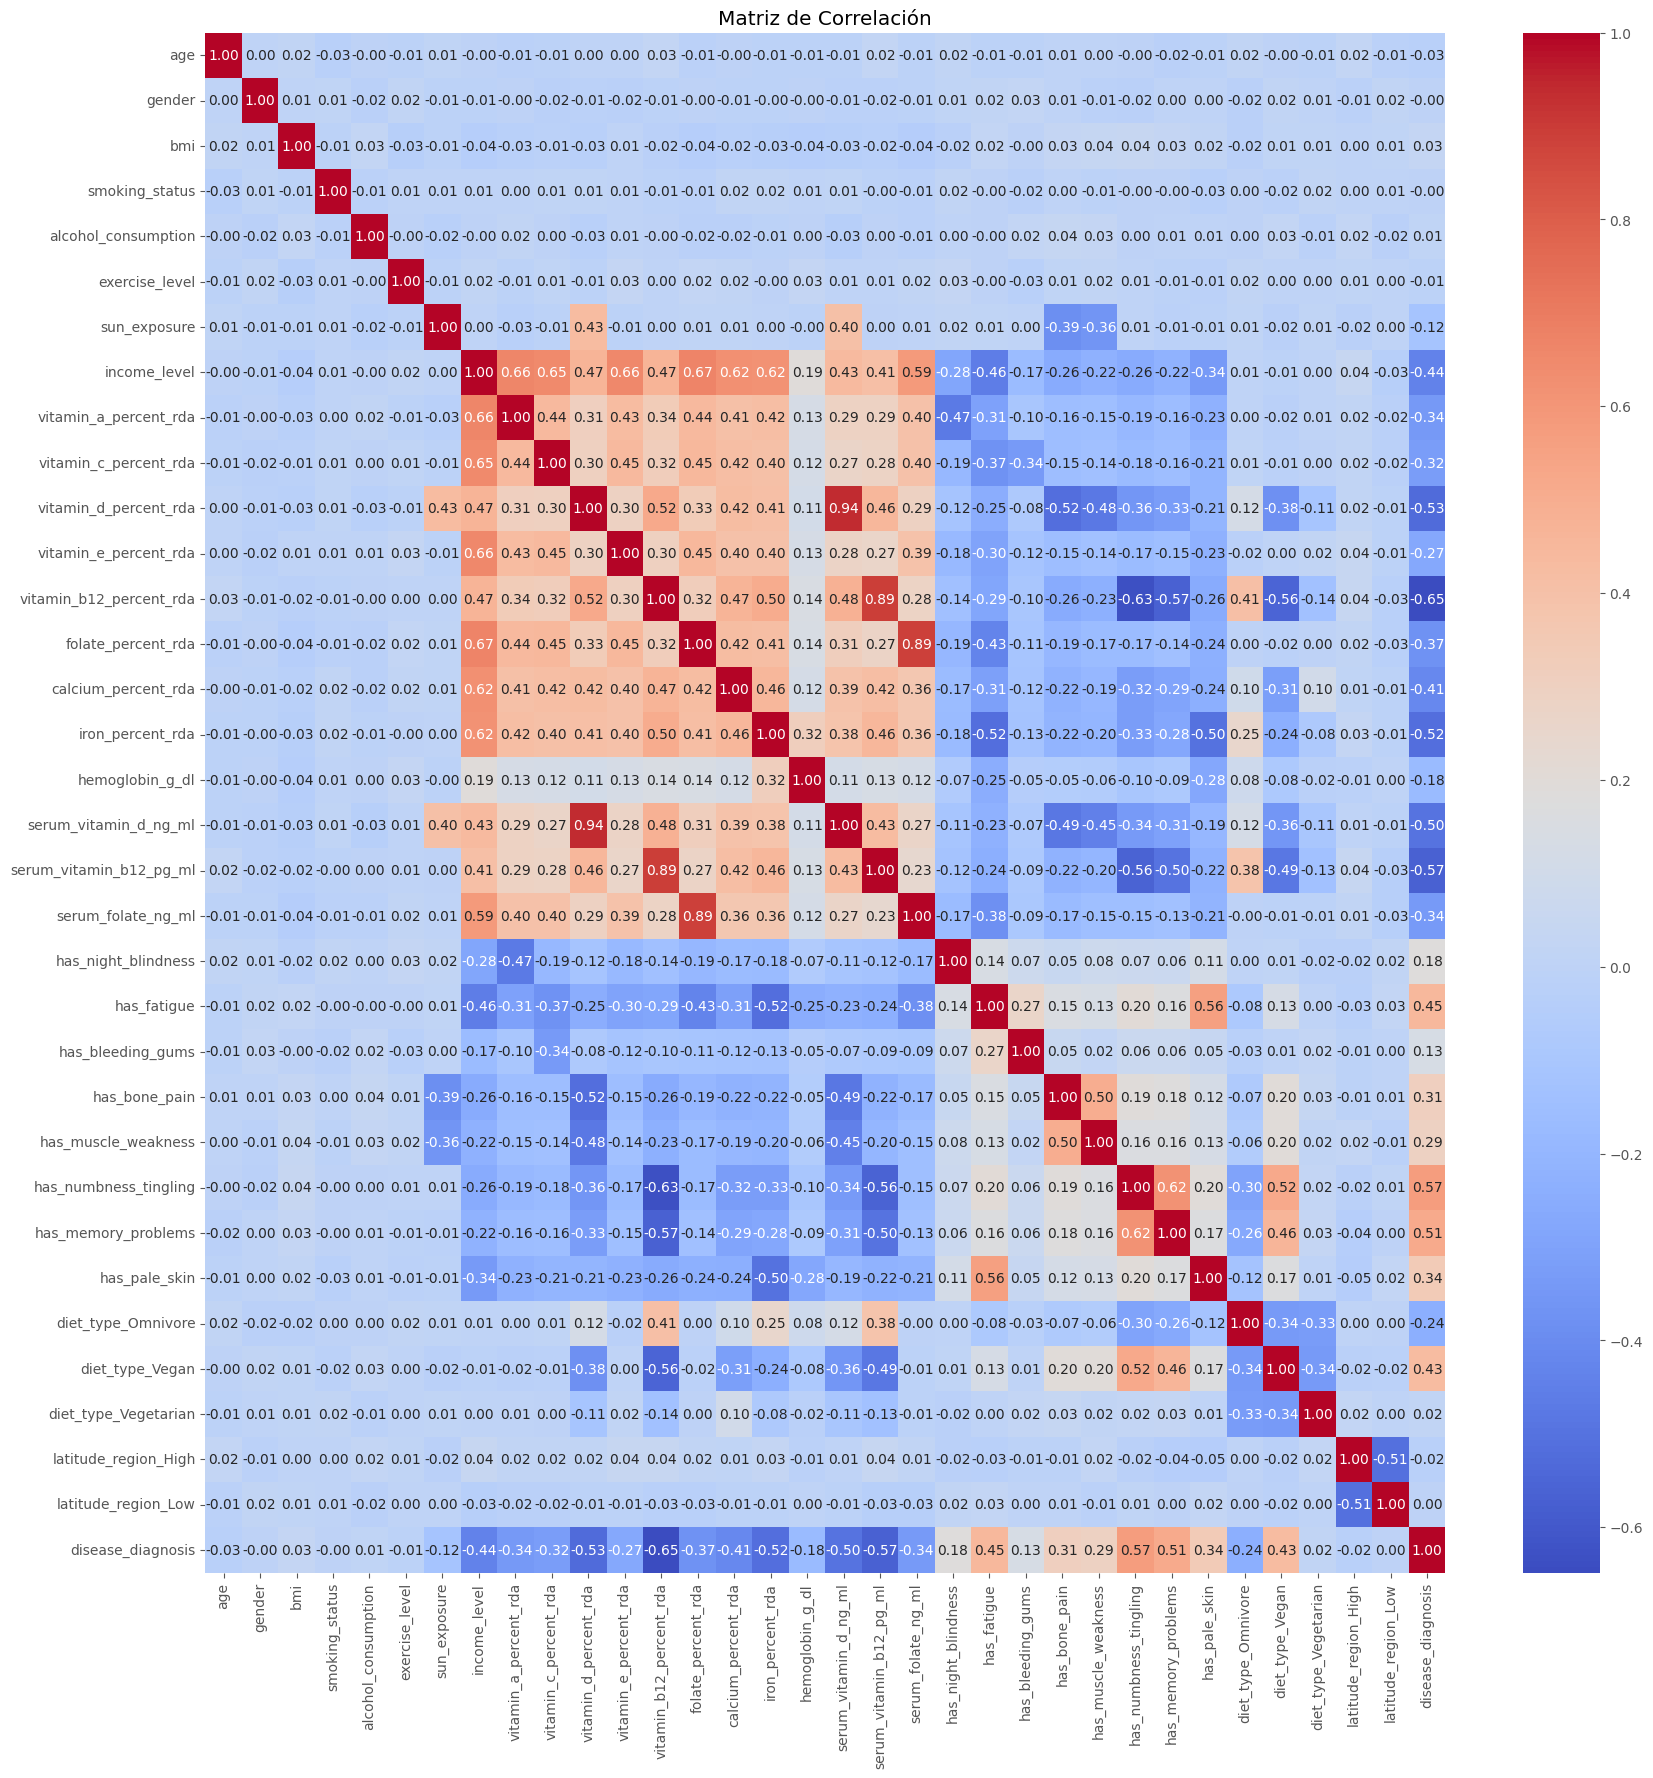

In [342]:
corr_matrix = df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

**Explicación:** Listamos las variables que tienen mayor correlación con el target `disease_diagnosis`. Se puede apreciar que estas variables son `vitamin_b12_percent_rda`, `has_numbness_tingling`, `serum_vitamin_b12_pg_ml`, `vitamin_d_percent_rda` y `iron_percent_rda`. Se puede apreciar que dentro de las variables más relacionadas al target contienen datos del consumo actual y recomendado de vitaminas por la persona, así como algunos de los síntomas que vienen relacionados con la deficiencia vitamínica.

In [343]:
corr_target = df.corr()['disease_diagnosis'].drop('disease_diagnosis')
top_corrs = corr_target.abs().sort_values(ascending=False).head(5)
print("Top 5 Correlaciones con respecto a disease_diagnosis:")
print(top_corrs)

Top 5 Correlaciones con respecto a disease_diagnosis:
vitamin_b12_percent_rda    0.648530
has_numbness_tingling      0.572700
serum_vitamin_b12_pg_ml    0.565776
vitamin_d_percent_rda      0.531530
iron_percent_rda           0.515066
Name: disease_diagnosis, dtype: float64


**Explicación:** Graficamos las distribuciones de las 33 variables y el target para analizar su forma. Se puede observar que algunas variables como `bmi`, `hemoglobin_g_dl`, entre otras, siguen una distribución normal, mientras que otras como `serum_vitamin_b12_pg_ml` presentan colas en su gráfica.

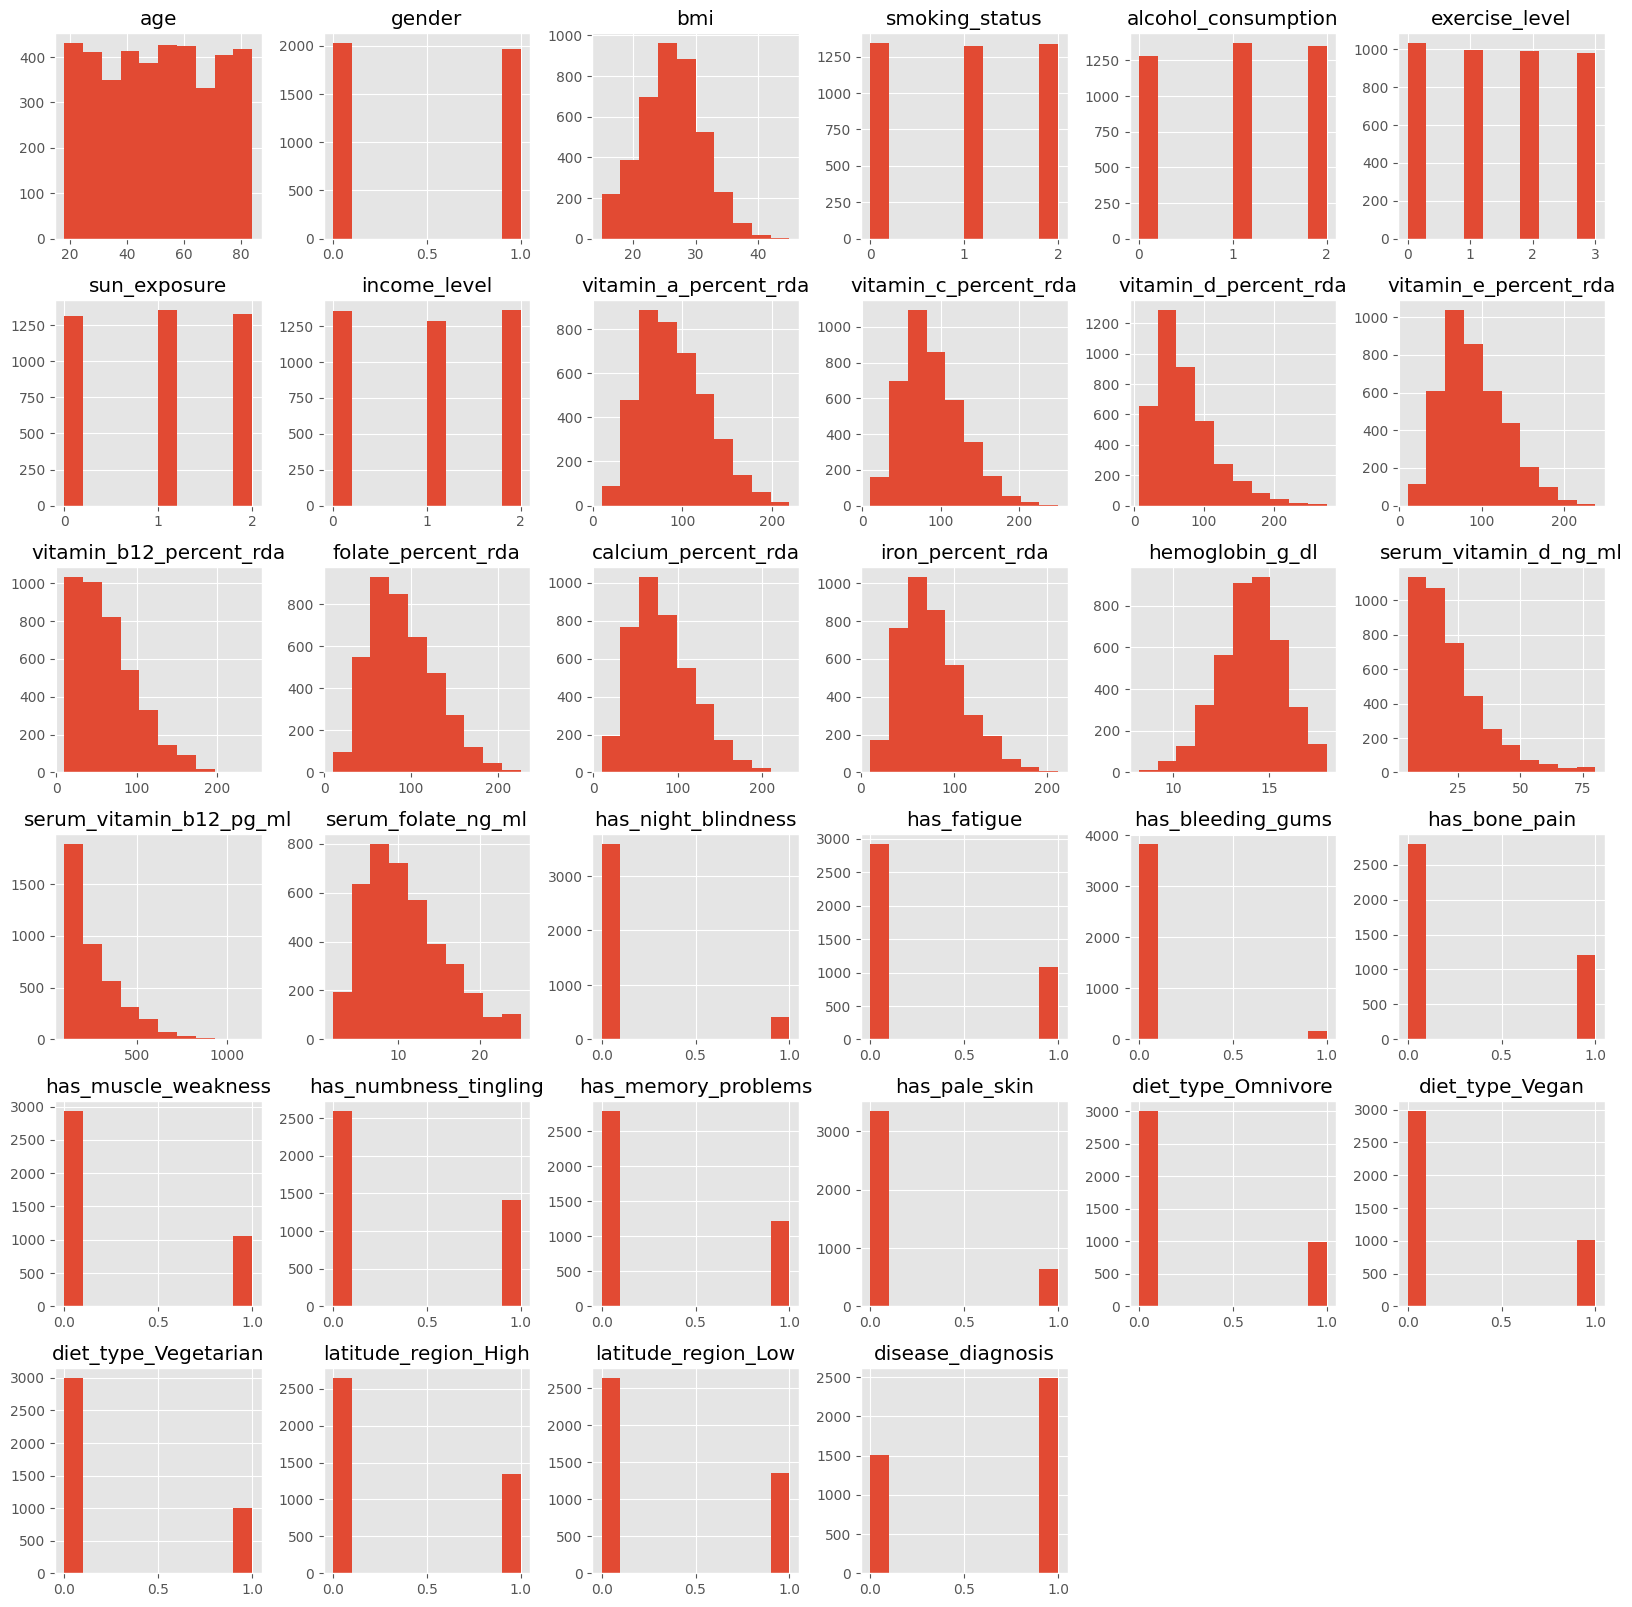

In [344]:
df.hist(figsize=(20, 20), bins=10)
plt.show()

**Explicación:** Para hacer una comparación más clara entre las distribuciones de las variables, calculamos el sesgo y curtosis para medir la asimetría de la gráfica y la concentración de los datos alrededor de la media. Se puede apreciar que en la gráfica de sesgo existe una tendencia positiva en las variables, es decir, la media de las variables se encuentra más cerca a los valores menores de su rango. Por otro lado, en la gráfica de curtosis predominan valores menores a 0, principalmente en las variables que describen los hábitos de la persona, lo que muestra que existe un balance de cuántas personas practican cada uno de los hábitos. Algo positivo a destacar es que la mayoría de consumos actuales y recomendados de vitaminas se encuentran cerca de 0 en la gráfica de curtosis, lo que significa que estos datos siguen una distribución normal.

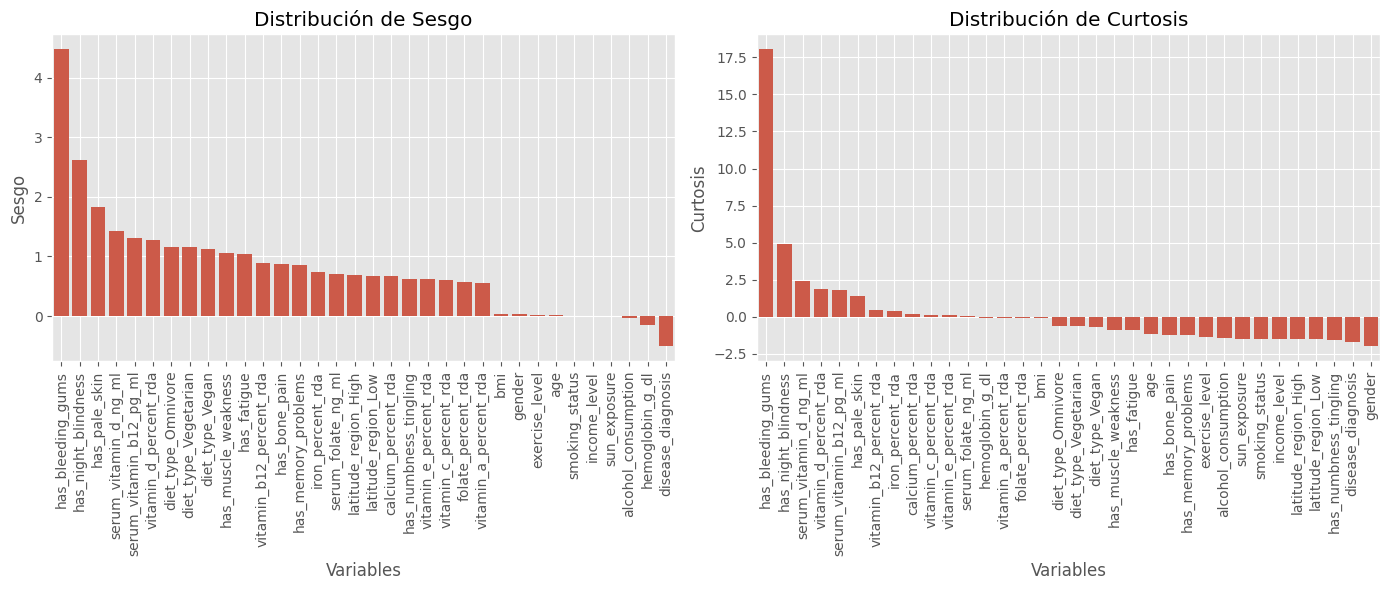

In [345]:
fig = plt.figure(figsize=(14,6))
ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)

skew = df.skew().sort_values(ascending=False)
kurtosis = df.kurtosis().sort_values(ascending=False)

sns.barplot(x=skew.index, y=skew.values, ax=ax0)
ax0.set_title("Distribución de Sesgo")
ax0.set_xlabel("Variables")
ax0.set_ylabel("Sesgo")
ax0.tick_params(axis='x', rotation=90)
ax0.grid(True)

sns.barplot(x=kurtosis.index, y=kurtosis.values, ax=ax1)
ax1.set_title("Distribución de Curtosis")
ax1.set_xlabel("Variables")
ax1.set_ylabel("Curtosis")
ax1.tick_params(axis='x', rotation=90)
ax1.grid(True)

plt.tight_layout()
plt.show()

#**2. Design and Training of the Single-Neuron Model:**

**Explicación:** Separamos nuestro target del resto de variables, inicializando `x` y `y` para su uso en el entrenamiento del modelo.

In [346]:
y = df['disease_diagnosis']
x = df.drop('disease_diagnosis', axis=1)

**Explicación:** Aplicamos `test_split` a los datos para separar en datos de entrenamiento y de validación. En este caso, realizamos esta separación con una proporción 80/20.

In [347]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle = True)

**Explicación:** Aplicamos `StandardScaler` para normalizar los datos, permitiendo su uso dentro de PCA.

In [348]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Explicación:** Definimos nuestro modelo neuronal con 33 variables, 1 neurona y con la fórmula de activación sigmoide, la cual se utiliza para la clasificación de modelos binarios, ya que regresa como valor 0 o 1.

In [349]:
def get_model():
  model = tf.keras.Sequential([
      tf.keras.layers.InputLayer(shape=(33,)),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  return model

**Explicación:** Imprimimos el resumen del modelo para confirmar su tamaño y la cantidad de parámetros.

In [350]:
model = get_model()
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 1)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34 (136.00 B)

 Trainable params: 34 (136.00 B)

 Non-trainable params: 0 (0.00 B)

**Explicación:** Compilamos nuestro modelo y especificamos la fórmula de loss `binary_crossentropy`, ya que esta nos devuelve una función convexa, lo que nos permite buscar el punto mínimo de costo. Además, utilizamos de optimizer `adam`, un algoritmo de descenso de gradiente que ajusta las tasas de aprendizaje durante el entrenamiento. De acuerdo con Kingma y Ba (2014), este algoritmo de optimización es eficiente y requiere menos uso de memoria, por lo que nos sirve para realizar el entrenamiento del modelo más rápido.

In [351]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Explicación:** Entrenamos el modelo con las variables `X_train` y `y_train`. Para esto, decidimos que los hiperparámetros fueran los siguientes:
- `epochs`=50: Entrena varias veces con los datos, limitándolo a 50 iteraciones para prevenir overfitting.
- `batch_size`=32: Permite que el ajuste de pesos sea constante.
- `validation_split`=0.2: Mantiene la misma proporción de datos para entrenamiento y validación que el split original.
- `learning_rate`: Al utilizar `adam` como optimizador, toma por defecto el valor de 0.001, un cambio no muy grande pero significativo al usar batches de ese tamaño.

In [352]:
history = model.fit(X_train,
                    y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4045 - loss: 1.0183 - val_accuracy: 0.5531 - val_loss: 0.7325
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6059 - loss: 0.6989 - val_accuracy: 0.7188 - val_loss: 0.5517
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7212 - loss: 0.5665 - val_accuracy: 0.7844 - val_loss: 0.4599
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7951 - loss: 0.4645 - val_accuracy: 0.8156 - val_loss: 0.4082
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8108 - loss: 0.4200 - val_accuracy: 0.8422 - val_loss: 0.3743
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8233 - loss: 0.3988 - val_accuracy: 0.8578 - val_loss: 0.3506
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8447 - loss: 0.3683 - val_accuracy: 0.8703 - val_loss: 0.3332
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8590 - loss: 0.3533 - val_accuracy: 0.8781 - val_loss:

#**3. Learning Curve Analysis**

**Explicación:** En la gráfica de línea de aprendizaje podemos apreciar cómo se fue entrenando nuestro modelo y cómo su accuracy va aumentando conforme a las pruebas, hasta llegar a una meseta donde se estaciona en un cierto número. Con esto, podemos apreciar que el ajuste del modelo es ideal, ya que la brecha entre las gráficas de train y test es menor, manteniendo al mismo tiempo un accuracy alto.

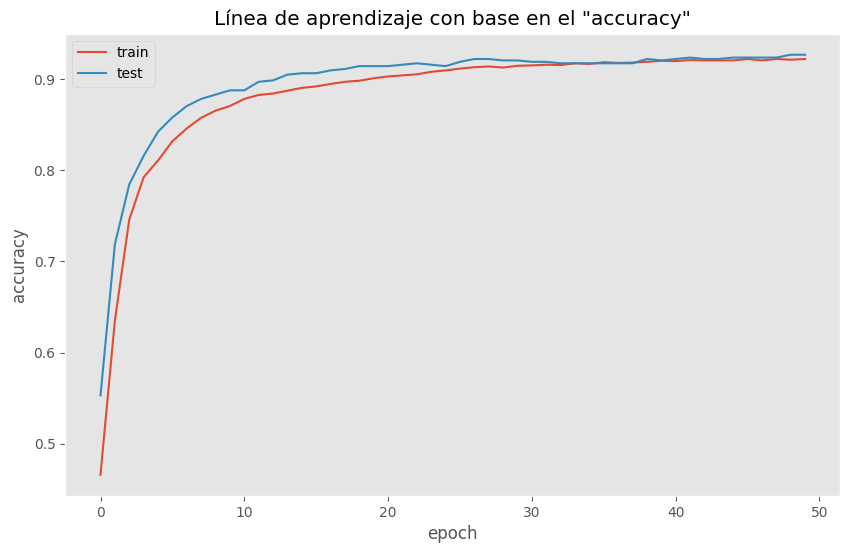

In [353]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Línea de aprendizaje con base en el "accuracy"')
plt.legend(['train', 'test'])
plt.grid();
plt.show()

**Explicación:** En la gráfica de línea de costo podemos apreciar cómo fue cambiando su valor conforme se entrenaba el modelo y cómo este tiende a 0, confirmando así que el ajuste del modelo es ideal al ir reduciendo la cantidad de errores conforme avanzaba a través de las épocas de entrenamiento.

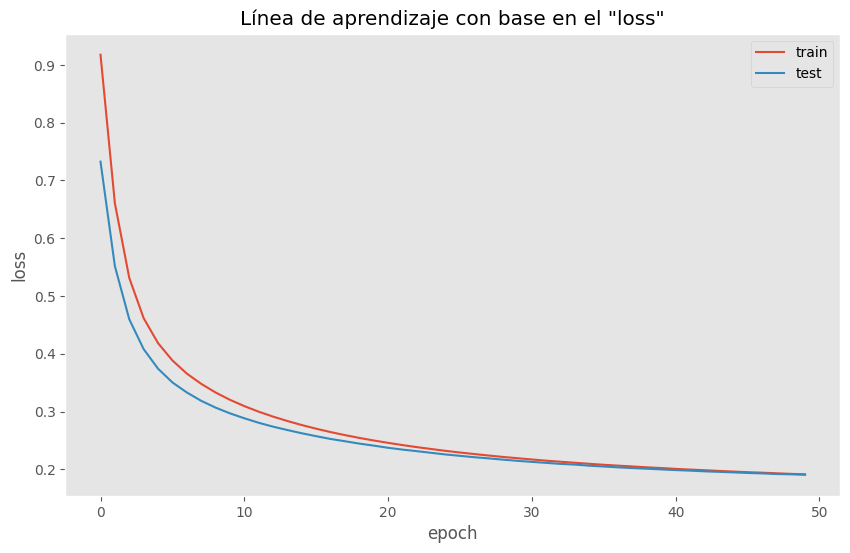

In [354]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Línea de aprendizaje con base en el "loss"')
plt.legend(['train', 'test'])
plt.grid();
plt.show()

#**4. Model Evaluation and Testing Data**

**Explicación:** Para poner a prueba la validez de nuestro modelo entrenado, generamos una línea de datos al azar y revisamos qué tan cerca está la predicción del target.

In [355]:
indx = np.random.randint(low=0, high=y_test.shape[0])
xi = np.array([X_test[indx,:]])
prediction = model.predict(xi)
print(f"Input {xi} \t Target: {y_test.iloc[indx]} \t Prediction: {prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Input [[ 0.79970168  1.02660376 -2.1313896  -1.231862    1.20829436  0.45883943
  -1.24227273  1.21066625  1.54133186 -0.22940269  0.11729694  0.59395355
  -0.73511393 -0.23735196  2.36551454 -0.70887509  0.27422223  0.39068096
  -0.81683608 -0.45101596 -0.34251779 -0.59900838 -0.21864619 -0.65075921
  -0.60238029  1.34792485  1.52525517 -0.42982135 -0.57590689 -0.58649222
  -0.5658021   1.40301821 -0.71125407]] 	 Target: 1 	 Prediction: 0.9800


**Explicación:** Generamos una matriz de confusión para ver la distribución de las predicciones del modelo con respecto a su etiqueta real. Se puede apreciar que la mayoría de los datos se concentran en la diagonal de la matriz, significando que una gran parte de las predicciones se realizaron correctamente.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


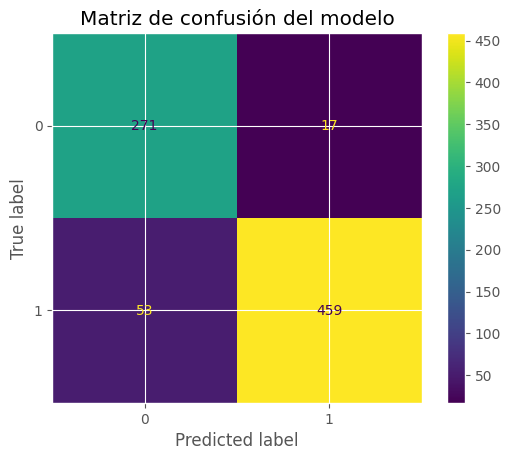

In [356]:
y_predictions = model.predict(X_test) > 0.5
c_matrix = confusion_matrix(y_true=y_test, y_pred=y_predictions)

display_matrix = ConfusionMatrixDisplay(confusion_matrix=c_matrix)
display_matrix.plot()
plt.title('Matriz de confusión del modelo')
plt.show()

**Explicación:** Aplicamos diferentes métricas estadísticas al modelo para verificar su rendimiento. Se puede apreciar que el modelo tiene métricas bastante altas en general, lo que validan su buen rendimiento. La distribución de métricas es la siguiente:
- **Accuracy:** Mide la cantidad de predicciones correctas con respecto al número total de predicciones. Nuestro modelo tiene un accuracy de 91.25%
- **Precision:** Mide la proporción de predicciones positivas que realmente lo son. Nuestro modelo tiene una precision de 96.43%  
- **Recall:** Se enfoca en la disminución de falsos negativos dentro del modelo. Nuestro modelo tiene un recall de 89.65%  
- **Specificity:** Se enfoca en la disminución de falsos positivos dentro del modelo. Nuestro modelo tiene un specificity de 94.10%
- **F1 Score:** Combina las métricas de recall y precision en una sola, balanceando así la medición de falsos positivos y negativos. Nuestro modelo tiene un F1 Score de 92.91%  
  
(Caballar & Stryker, 2025)  
  
Para este modelo en específico, la métrica más importante es Recall, ya que al tener un contexto médico donde se debe diagnosticar correctamente si la persona tiene o no una deficiencia vitamínica, es importante tener la menor cantidad de falsos negativos posible.

In [357]:
def get_performance_metrics(c_matrix):
  tn, fp, fn, tp = c_matrix[0][0], c_matrix[0][1], c_matrix[1][0], c_matrix[1][1]

  accuracy_normal = (tp + tn) / (tp + tn + fp + fn)
  precision_normal = tp / (tp + fp)
  recall_normal = tp / (tp + fn)
  specificity_normal = tn / (tn + fp)
  f1_score_normal = 2 * (precision_normal * recall_normal) / (precision_normal + recall_normal)
  return accuracy_normal, precision_normal, recall_normal, specificity_normal, f1_score_normal

accuracy_normal, precision_normal, recall_normal, specificity_normal, f1_score_normal = get_performance_metrics(c_matrix)

print(f"Accuracy: {accuracy_normal:.4f}")
print(f"Precision: {precision_normal:.4f}")
print(f"Recall: {recall_normal:.4f}")
print(f"Specificity: {specificity_normal:.4f}")
print(f"F1 Score: {f1_score_normal:.4f}")

Accuracy: 0.9125
Precision: 0.9643
Recall: 0.8965
Specificity: 0.9410
F1 Score: 0.9291


#**5. Save the Model**

**Explicación:** En esta parte guardamos el modelo para poder utilizarlo en futuras pruebas. Si fuera necesario seguir con el entrenamiento del modelo, este guardado nos permite hacer rollback en caso de que el rendimiento sea afectado negativamente por la modificación de sus parámetros.

In [358]:
model.save('single-neuron-model-vitamin-deficiency.keras')

**Explicación:** Cargamos el modelo guardado para verificar que se guardó correctamente.

In [359]:
model_file = 'single-neuron-model-vitamin-deficiency.keras'
new_model = tf.keras.models.load_model(model_file, compile = True, safe_mode = True)
new_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 1)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104 (420.00 B)

 Trainable params: 34 (136.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70 (284.00 B)

**Explicación:** Probamos el modelo cargado con los valores de prueba.

In [360]:
loss, accuracy = new_model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9146 - loss: 0.1956  
Test Accuracy: 0.9125


#**6. Principal Component Analysis (PCA) Extension**

1. Obtenemos datos:

**Explicación:** Repetimos el proceso anterior, separando las variables y el target en `x` y `y`.

In [361]:
y = df['disease_diagnosis']
x = df.drop('disease_diagnosis', axis=1)

2. Data standardisation:

**Explicación:** Estandarizamos las variables por medio de la siguiente fórmula, esto para evitar que la variación de rango de números en los datos afecte los pesos que se le dan en la matriz de covarianza y en los demás pasos del proceso. Al estandarizarlo, todos los datos se rigen en un mismo rango y contribuyen lo mismo, evitando que PCA termine sesgado por alguna de las variables.

**Fórmula:**
$$
X_{z} = \frac{X - \mu}{\sqrt{\sigma^2 + \varepsilon}}
$$

- $X_{z}$ = X estandarizada  
- $X$ = Columnas independientes
- $\mu$ = Promedio de X  
- $\sigma$ = Desviación estándar de X  
- $\varepsilon$ = Constante pequeña para evitar división entre cero ($10^{-8}$)

In [362]:
X_standar = (x - x.mean()) / np.sqrt(x.std()**2 + 1e-8)
Y_standar = (y - y.mean()) / np.sqrt(y.std()**2 + 1e-8)

3. Covariance matrix:

**Explicación:** Generamos la matriz de covarianza de las variables `X` para ver cómo se relacionan entre sí. Al haber estandarizado nuestros valores, estos muestran una tabla similar a la de correlación. Se puede apreciar que igualmente como en la matriz de correlación, existe colinealidad entre variables, como el consumo recomendado y actual de vitaminas (columnas 8-19), así como el consumo de vitaminas con el nivel de ingresos (columna 7 con columnas 8-19). En este caso, esta colinealidad no será un problema, ya que el uso de PCA hará que cada uno de los componentes principales estén no correlacionados entre sí.

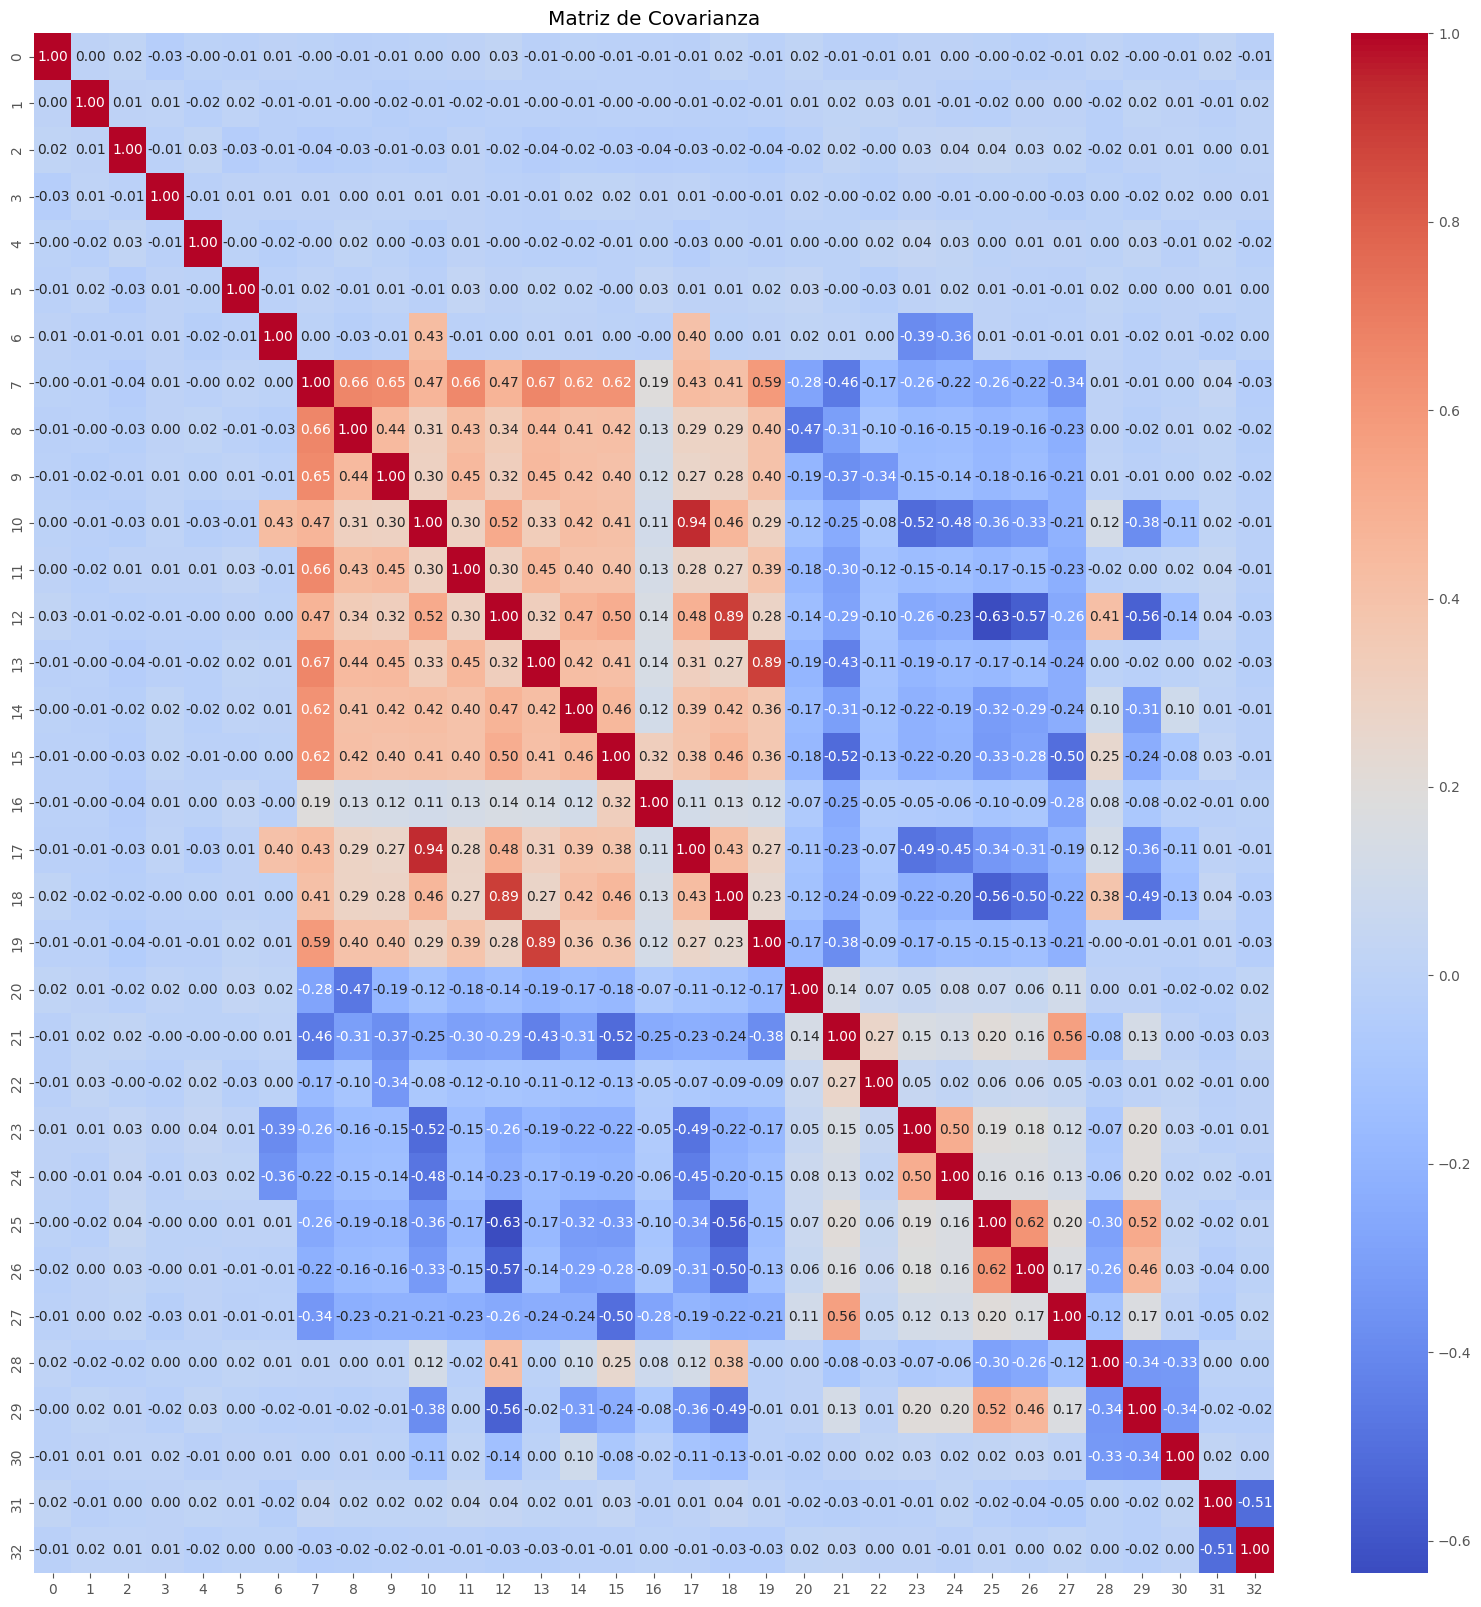

In [363]:
cov_matrix = np.cov(X_standar, rowvar=False)
plt.figure(figsize=(20, 20))
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Covarianza")
plt.show()

4. Eigenvalues and eigenvectors:

**Explicación:** Obtenemos los eigenvalues y eigenvectors. Los eigenvectors son las direcciones de la que los datos no se salen de una misma línea al aplicar una transformación lineal, mientras que los eigenvalues son la magnitud de cómo se moverían los datos al estar en estos vectores. El papel de estos componentes en el PCA es obtener estos datos para poder calcular nuevos valores, moviéndolos sobre los eigenvectors y maximizando la varianza, para reducir la relación entre estos.

In [364]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) #Funcion de numpy para sacar valores y vectores propios
print("Valores propios:\n", eigenvalues.round(2))
print("Vectores propios:\n", eigenvectors.round(2))

Valores propios:
 [0.06 0.08 0.1  0.12 0.22 0.36 0.37 0.38 0.42 0.46 0.48 0.49 0.51 0.53
 0.6  0.69 0.71 0.78 0.84 0.95 0.96 0.99 1.   1.02 1.05 1.1  1.12 1.35
 1.42 1.51 2.13 2.82 7.37]
Vectores propios:
 [[-0.01 -0.    0.01 ...  0.02 -0.02 -0.  ]
 [-0.   -0.01 -0.   ... -0.   -0.    0.01]
 [-0.   -0.01 -0.   ...  0.01  0.01  0.02]
 ...
 [ 0.08  0.15 -0.01 ... -0.01  0.05  0.02]
 [-0.01  0.   -0.   ...  0.06  0.01 -0.02]
 [-0.    0.   -0.01 ... -0.04 -0.02  0.01]]


5.  Transformation matrix:

**Explicación:** Ordenamos los eigenvectors con respecto al eigenvalue en orden descendente. Generamos la matriz de transformación que nos servirá para cambiar los valores de los datos y los ordenamos, dándole prioridad a los valores mayores al inicio para así utilizar aquellos componentes principales que retienen la mayor cantidad de los datos posible.

In [365]:
indice = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indice]
F = eigenvectors[:, indice]
print("Matriz de transformación:\n", F.round(2))

Matriz de transformación:
 [[-0.   -0.02  0.02 ...  0.01 -0.   -0.01]
 [ 0.01 -0.   -0.   ... -0.   -0.01 -0.  ]
 [ 0.02  0.01  0.01 ... -0.   -0.01 -0.  ]
 ...
 [ 0.02  0.05 -0.01 ... -0.01  0.15  0.08]
 [-0.02  0.01  0.06 ... -0.    0.   -0.01]
 [ 0.01 -0.02 -0.04 ... -0.01  0.   -0.  ]]


6. Explained variance:

**Explicación:** Calculamos los porcentajes de varianza de cada componente. Se puede apreciar que solo con el primer componente ya se explica un 22.35% de los datos, con las primeras dos 30.89% y con las primeras tres 37.34%, lo que si bien no es la mayoría de datos, si puede ser una representación buena de los datos en general. Si quisiéramos explicar más del 95% de la varianza, necesitamos al menos 26 componentes principales. En la gráfica de proporción de varianza explicada podemos observar cómo la varianza va aumentando mientras más componentes se agregan, siendo el primer componente el más significativo.

**Formula:**
$$
V_{\lambda_j} = \frac{\lambda_j}{\sum_{i=1}^{M} \lambda_i}
$$

- $V_{\lambda_j}$ = Varianza del valor propio j
- ${\lambda_j}$ = Valor propio j
- $M$ = Cantidad de valores propios
- ${\lambda_j}$ = Valor propio i


Porcentajes de Varianza:
 [22.35  8.55  6.45  4.59  4.31  4.09  3.38  3.35  3.18  3.08  3.04  3.01
  2.91  2.87  2.55  2.36  2.16  2.1   1.81  1.6   1.54  1.48  1.45  1.4
  1.26  1.15  1.12  1.1   0.66  0.38  0.32  0.25  0.17]
Porcentajes acumulados de Varianza: 
 [ 22.35  30.89  37.34  41.93  46.24  50.33  53.72  57.06  60.24  63.32
  66.36  69.37  72.27  75.14  77.69  80.05  82.21  84.31  86.12  87.72
  89.26  90.74  92.19  93.59  94.85  96.    97.12  98.22  98.88  99.26
  99.58  99.83 100.  ]


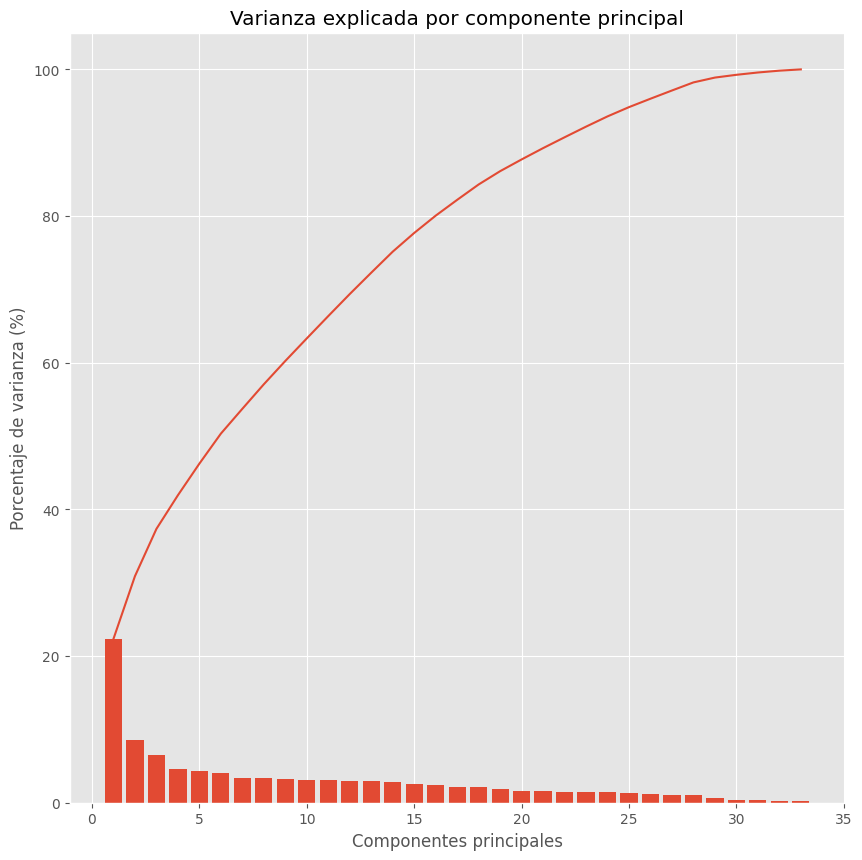

In [366]:
explained_var = (eigenvalues / eigenvalues.sum()) * 100
print("Porcentajes de Varianza:\n", explained_var.round(2))
acumulado = np.cumsum(explained_var)
print("Porcentajes acumulados de Varianza: \n", acumulado.round(2))

plt.figure(figsize=(10, 10))
plt.bar(range(1, len(eigenvalues)+ 1), explained_var)
plt.plot(range(1, len(eigenvalues)+ 1), acumulado)
plt.title("Varianza explicada por componente principal")
plt.xlabel("Componentes principales")
plt.ylabel("Porcentaje de varianza (%)")
plt.show()

7. First three Principal Components

**Explicación:** Ya con nuestra matriz de transformación, podemos aplicar el cambio de datos con los primeros los componentes seleccionados, aplicando la fórmula. En la siguiente tabla podemos apreciar cómo quedaron estos componentes con nuevos valores, teniendo así un rango mucho menor comparado a los valores originales. Se eligieron los primeros 3 componentes, ya que a partir del cuarto componente, el aporte de estos es menos significativo.

**Formula:**
$$
X_{pca} = X_{z} F
$$

- $X_{pca}$ = Valores de X como componentes principales
- $X_{z}$ = X estandarizada
- $F$ = Matriz de transformación


In [367]:
principales_3 = pd.DataFrame(X_standar.dot(F[:, :3])) #Los primeros 3 componentes
principales_3.head()

,0,1,2
0,-4.475565,0.895523,-1.511695
1,1.005980,-1.496553,2.611631
2,-3.737002,-0.882067,1.549310
3,1.821781,0.048308,-1.827133
4,-1.976763,0.736803,-0.040149


**Explicación:** Graficamos los 3 componentes y separamos las clasificaciones por color, donde Azul = Healthy y Amarillo = Deficiencia de vitaminas. Se puede apreciar cómo la mayoría de los datos están agrupados hacia las orillas, a excepción del centro, donde los grupos se llegan a mezclar entre sí, pero en general, la clasificación se

In [368]:
principales_3["Clase"] = y.values
fig = px.scatter_3d(principales_3, x=0, y=1, z=2, color="Clase", title="Visualización 3D de los primeros componentes principales (PCA)")
fig.show()

#**7. Train a New Single-Neuron model using PCA features**

**Explicación:** Separamos nuestro target del resto de variables, inicializando `x` y `y` para su uso en el entrenamiento del modelo, pero esta vez `x` son los componentes que obtuvimos con el PCA.

In [369]:
X = pd.DataFrame(X_standar.dot(F[:, :3]))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = True)

**Explicación:** Aplicamos `test_split` a los datos para separar en datos de entrenamiento y de validación, realizamos esta separación con una proporción 80/20.

In [370]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Explicación:** Definimos nuestro modelo neuronal con 3 variables, 1 neurona y con la fórmula de activación sigmoidal, la cual se utiliza para la clasificación de modelos binarios, ya que regresa como valor 0 o 1.

In [371]:
def get_model():
  model_PCA = tf.keras.Sequential([
      tf.keras.layers.InputLayer(shape=(3,)),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  return model_PCA

**Explicación:** Imprimimos el resumen del modelo para confirmar su tamaño y la cantidad de parámetros.

In [372]:
model_PCA = get_model()
model_PCA.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

**Explicación:** Compilamos nuestro modelo y especificamos la fórmula de loss como `binary_crossentropy` y utilizamos de optimizer `adam`, igual que en el modelo anterior.

In [373]:
model_PCA.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Explicación:** Entrenamos el modelo con las variables `X_train` y `y_train`, y con los hiperparámetros iguales al modelo anterior:
- `epochs`=50: Entrena varias veces con los datos, limitándolo a 50 iteraciones para prevenir overfitting.
- `batch_size`=32: Permite que el ajuste de pesos sea constante.
- `validation_split`=0.2: Mantiene la misma proporción de datos para entrenamiento y validación que el split original.
- `learning_rate`: Al utilizar `adam` como optimizador, toma por defecto el valor de 0.001, un cambio no muy grande pero significativo al usar batches de ese tamaño.

In [374]:
history_PCA = model_PCA.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6192 - loss: 0.6710 - val_accuracy: 0.6266 - val_loss: 0.6480
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6615 - loss: 0.6249 - val_accuracy: 0.6719 - val_loss: 0.6072
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7183 - loss: 0.5909 - val_accuracy: 0.7312 - val_loss: 0.5722
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7637 - loss: 0.5554 - val_accuracy: 0.7672 - val_loss: 0.5417
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7943 - loss: 0.5284 - val_accuracy: 0.7922 - val_loss: 0.5155
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8263 - loss: 0.4960 - val_accuracy: 0.8250 - val_loss: 0.4925
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8369 - loss: 0.4842 - val_accuracy: 0.8484 - val_loss: 0.4727
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8527 - loss: 0.4690 - val_accuracy: 0.8531 - val_loss:

**Explicación:** En la gráfica de línea de aprendizaje podemos apreciar cómo se fue entrenando nuestro modelo y cómo su accuracy va aumentando conforme a las pruebas, hasta llegar a una meseta donde casi se estabilizan ambas líneas, podemos notar que en este modelo el accuracy máximo se queda por debajo de 0.90 y que ambas rectas tienen algo de ruido a largo de las épocas.

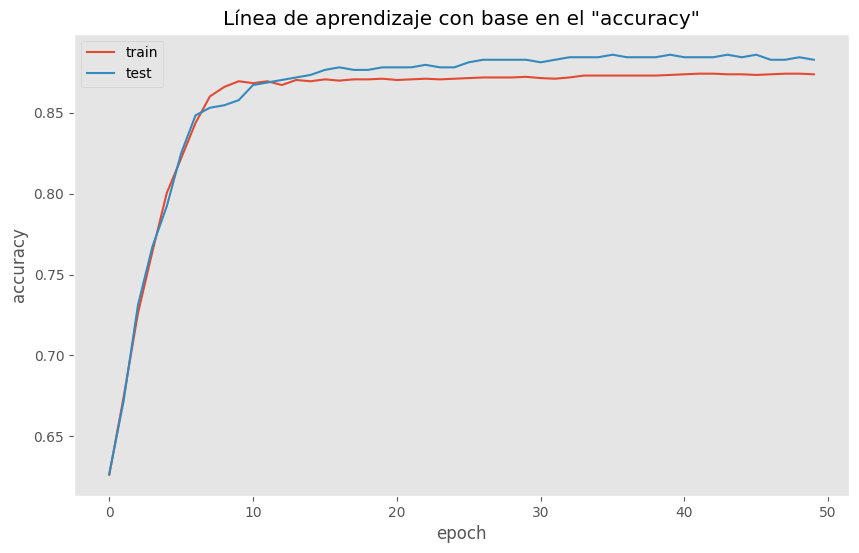

In [375]:
plt.figure(figsize=(10, 6))
plt.plot(history_PCA.history['accuracy'])
plt.plot(history_PCA.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'])
plt.title('Línea de aprendizaje con base en el "accuracy"')
plt.grid();
plt.show()

**Explicación:** En la gráfica de línea de costo podemos apreciar cómo fue cambiando su valor conforme se entrenaba el modelo y cómo este tiende a 0, confirmando así que el ajuste del modelo es adecuado al ir reduciendo la cantidad de errores conforme avanzaba a través de las épocas de entrenamiento.

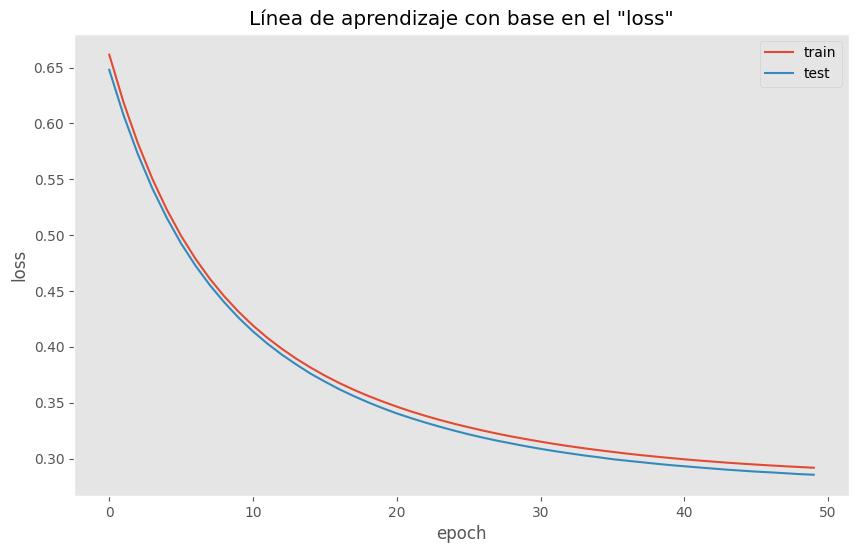

In [376]:
plt.figure(figsize=(10, 6))
plt.plot(history_PCA.history['loss'])
plt.plot(history_PCA.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.title('Línea de aprendizaje con base en el "loss"')
plt.grid();
plt.show()

**Explicación:** Para poner a prueba la validez de nuestro modelo con PCA entrenado, generamos una línea de datos al azar y revisamos qué tan cerca está la predicción del target.

In [377]:
indx = np.random.randint(low=0, high=y_test.shape[0])
xi = np.array([X_test[indx,:]])
prediction = model_PCA.predict(xi)
print(f"Input {xi} \t Target: {y_test.iloc[indx]} \t Prediction: {prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Input [[0.16594598 1.14866674 0.94602248]] 	 Target: 1 	 Prediction: 0.8677


**Explicación:** Generamos una matriz de confusión para ver la distribución de las predicciones del modelo con respecto a su etiqueta real. Se puede apreciar que la mayoría de los datos se concentran en la diagonal de la matriz, significando que una gran parte de las predicciones se realizaron correctamente.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


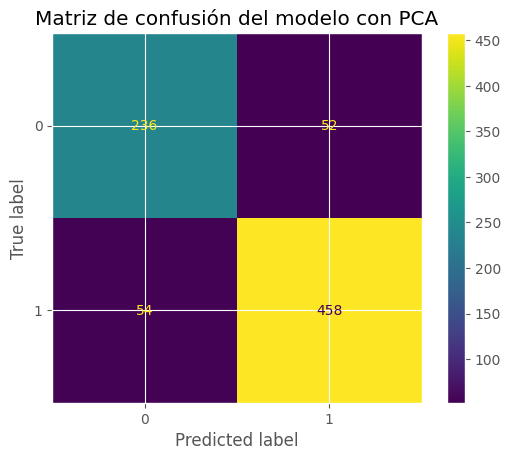

In [378]:
y_predictions = model_PCA.predict(X_test) > 0.5
c_matrix = confusion_matrix(y_true=y_test, y_pred=y_predictions)

display_matrix = ConfusionMatrixDisplay(confusion_matrix=c_matrix)
display_matrix.plot()
plt.title('Matriz de confusión del modelo con PCA')
plt.show()

**Explicación:** Aplicamos diferentes métricas estadísticas al modelo para verificar su rendimiento. Se puede apreciar que el modelo tiene métricas bastante altas en general, lo que validan su buen rendimiento. La distribución de métricas es la siguiente:
- **Accuracy:** Mide la cantidad de predicciones correctas con respecto al número total de predicciones. Nuestro modelo tiene un accuracy de 86.75%
- **Precision:** Mide la proporción de predicciones positivas que realmente lo son. Nuestro modelo tiene una precision de 89.80%  
- **Recall:** Se enfoca en la disminución de falsos negativos dentro del modelo. Nuestro modelo tiene un recall de 89.45%  
- **Specificity:** Se enfoca en la disminución de falsos positivos dentro del modelo. Nuestro modelo tiene un specificity de 81.94%
- **F1 Score:** Combina las métricas de recall y precision en una sola, balanceando así la medición de falsos positivos y negativos. Nuestro modelo tiene un F1 Score de 89.63%  
  

In [379]:
def get_performance_metrics(c_matrix):
  tn, fp, fn, tp = c_matrix[0][0], c_matrix[0][1], c_matrix[1][0], c_matrix[1][1]

  accuracy_PCA = (tp + tn) / (tp + tn + fp + fn)
  precision_PCA = tp / (tp + fp)
  recall_PCA = tp / (tp + fn)
  specificity_PCA = tn / (tn + fp)
  f1_score_PCA = 2 * (precision_PCA * recall_PCA) / (precision_PCA + recall_PCA)
  return accuracy_PCA, precision_PCA, recall_PCA, specificity_PCA, f1_score_PCA

accuracy_PCA, precision_PCA, recall_PCA, specificity_PCA, f1_score_PCA = get_performance_metrics(c_matrix)

print(f"Accuracy: {accuracy_PCA:.4f}")
print(f"Precision: {precision_PCA:.4f}")
print(f"Recall: {recall_PCA:.4f}")
print(f"Specificity: {specificity_PCA:.4f}")
print(f"F1 Score: {f1_score_PCA:.4f}")

Accuracy: 0.8675
Precision: 0.8980
Recall: 0.8945
Specificity: 0.8194
F1 Score: 0.8963


**Explicación:** En esta parte guardamos el modelo para poder utilizarlo en futuras pruebas.

In [380]:
model_PCA.save('single-neuron-model-vitamin-deficiency-PCA.keras')

**Explicación:** Cargamos el modelo guardado para verificar que se guardó correctamente.

In [381]:
model_file_PCA = 'single-neuron-model-vitamin-deficiency-PCA.keras'
new_model_PCA = tf.keras.models.load_model(model_file_PCA, compile = True, safe_mode = True)
new_model_PCA.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

**Explicación:** Probamos el modelo cargado con los valores de prueba.

In [382]:
loss, accuracy = new_model_PCA.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.2904  
Test Accuracy: 0.8675


#**8. Performance comparison and model selection:**

**Explicación:** Graficamos las rectas de ambos modelos para comparar su trayectoria y estabilidad durante el entrenamiento y revisar cuál de los modelos tuvo mejores resultados. Como se puede apreciar en las gráficas, el modelo entrenado sin aplicar PCA tuvo mejor rendimiento, con un accuracy mayor y loss menor. Sin embargo, en ambos se puede apreciar que el ajuste del modelo es ideal, tanto en el comportamiento de su aprendizaje como en la estabilidad del entrenamiento. Asimismo, la curva de entrenamiento del modelo con PCA inicia con mayor accuracy, pero su crecimiento es menor. También es importante considerar que el modelo con PCA únicamente utiliza 3 componentes principales en comparación con el modelo completo con 33 variables.

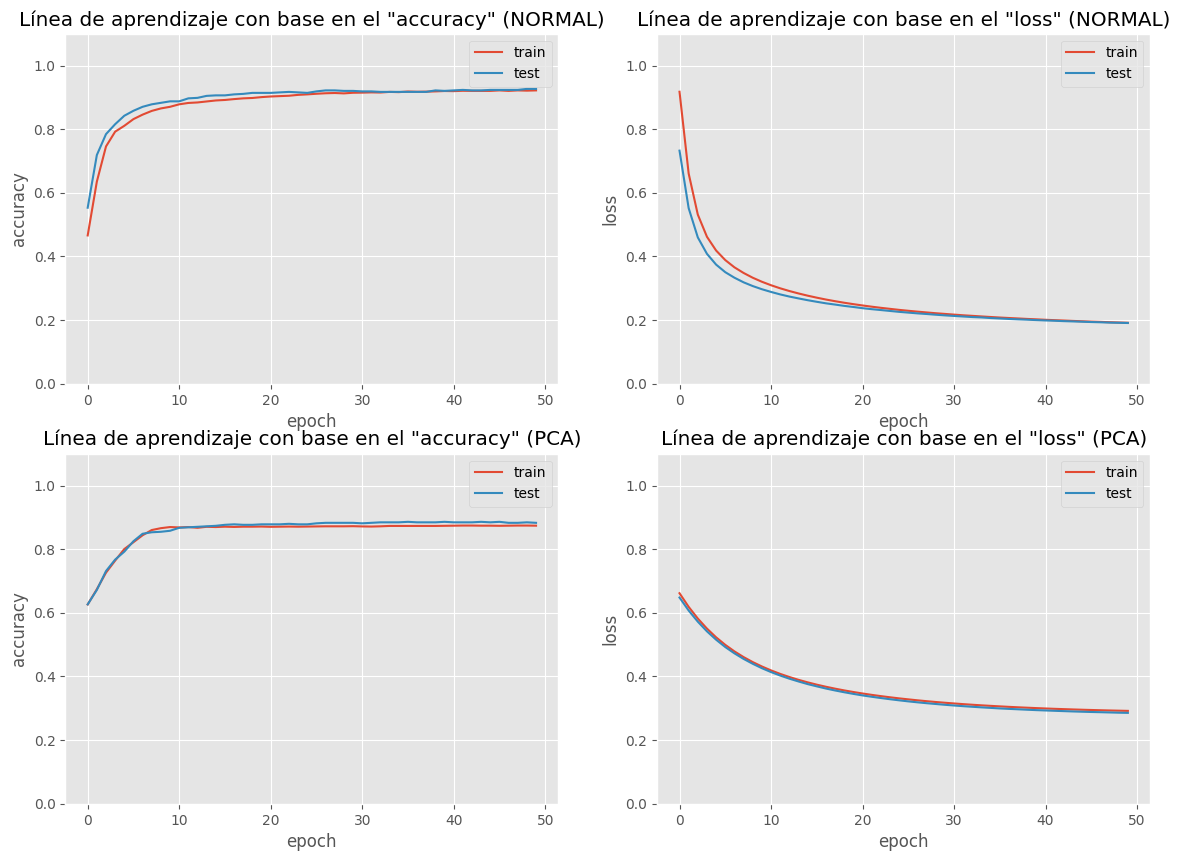

In [383]:
mpl.style.use("ggplot")
fig = plt.figure(figsize = (14, 10))
ax0 = fig.add_subplot(2,2,1)
ax1 = fig.add_subplot(2,2,2)
ax2 = fig.add_subplot(2,2,3)
ax3 = fig.add_subplot(2,2,4)

ax0.plot(history.history['accuracy'])
ax0.plot(history.history['val_accuracy'])
ax0.set_xlabel('epoch')
ax0.set_ylabel('accuracy')
ax0.set_title('Línea de aprendizaje con base en el "accuracy" (NORMAL)')
ax0.legend(['train', 'test'])
ax0.set_ylim(0, 1.1)
plt.grid();

ax1.plot(history.history['loss'])
ax1.plot(history.history['val_loss'])
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.set_title('Línea de aprendizaje con base en el "loss" (NORMAL)')
ax1.legend(['train', 'test'])
ax1.set_ylim(0, 1.1)
plt.grid();

ax2.plot(history_PCA.history['accuracy'])
ax2.plot(history_PCA.history['val_accuracy'])
ax2.set_xlabel('epoch')
ax2.set_ylabel('accuracy')
ax2.legend(['train', 'test'])
ax2.set_title('Línea de aprendizaje con base en el "accuracy" (PCA)')
ax2.set_ylim(0, 1.1)
plt.grid();

ax3.plot(history_PCA.history['loss'])
ax3.plot(history_PCA.history['val_loss'])
ax3.set_xlabel('epoch')
ax3.set_ylabel('loss')
ax3.legend(['train', 'test'])
ax3.set_title('Línea de aprendizaje con base en el "loss" (PCA)')
ax3.set_ylim(0, 1.1)
plt.grid();

plt.show()

**Explicación:** Después de entrenar ambos modelos y obtener sus métricas con los valores de prueba, generamos una tabla comparativa de las métricas de rendimiento. Como se puede apreciar, el modelo original tiene en general métricas mayores, con diferencias considerables como en Precision (96.4 vs 89.8), donde la diferencia es más del 6%, mientras que en otras como Recall (89.6% vs 89.5%) la diferencia es mínima, siendo menor a 1%. Como Recall es la métrica que más nos importa para este modelo, PCA es beneficioso porque logramos disminuir la dimensionalidad de 33 variables a solo 3 componentes, sacrificando en el proceso menos del 1% del Recall, lo cual lo mantiene un porcentaje muy aceptable del 89.5%. Considerando este pequeño sacrificio en el porcentaje del modelo con PCA, este sería el que desplegaríamos, ya que mantiene un buen porcentaje y con una dimensionalidad muy pequeña, haciéndolo más sencillo y rápido.

In [384]:
data = {
    'Modelo': ['Modelo sin PCA', 'Modelo con PCA'],
    'Accuracy': [accuracy_normal, accuracy_PCA],
    'Precision': [precision_normal, precision_PCA],
    'Recall': [recall_normal, recall_PCA],
    'Specificity': [specificity_normal, specificity_PCA],
    'F1 Score': [f1_score_normal, f1_score_PCA]
}

tabla_metricas = pd.DataFrame(data)
tabla_metricas

,Modelo,Accuracy,Precision,Recall,Specificity,F1 Score
0,Modelo sin PCA,0.9125,0.964286,0.896484,0.940972,0.929150
1,Modelo con PCA,0.8675,0.898039,0.894531,0.819444,0.896282


# **9. Personal Conclusions**
Después de haber realizado esta actividad, nos queda más claro el proceso de entrenamiento y prueba de un modelo neuronal, principalmente la configuración de hiperparámetros que se escogen como `epoch` y `batch_size`, así como su papel en el modelo.  

Algo que notamos del modelo neuronal es lo práctico y sencillo que es modelarlo, lo que permite crear rápidamente modelos de predicción, así como llevar a cabo su configuración.  

En este trabajo, el PCA tuvo un papel muy importante, ya que nos permitió ver su efecto positivo en el dataset adecuado. En este caso, nuestro dataset contaba con múltiples variables con colinealidad, lo que permitió tener una mejora considerable en la disminución de parámetros, manteniendo buenas métricas.  

Este trabajo se vio limitado por algunas de las características originales del dataset, ya que este en un principio estaba pensado para ser un dataset de clasificación multiclase, pero lo adaptamos para que se pudiera usar en clasificación binaria. Asimismo, algunas de las variables únicamente eran índices con cierta subjetividad, como los consumos de alcohol, cigarros y exposición al sol, cuando pudo haber sido mejor tener a la mano datos numéricos que pudieran ayudar al modelo a hacer una predicción más precisa.

Como sugerencia para mejorar este modelo, podríamos probar con distintos hiperparámetros y ver si así mejora nuestro modelo o empeora, como un `learning_rate` mayor, o más iteraciones.

# **Link Github:**
- https://github.com/antoniorivag/04-single-neuron
- https://github.com/jeronimoalvarezl/04-single-neuron

# **Fuente base de datos:**
- Vitamin Deficiency Disease Prediction Dataset. (2026, January 23). https://www.kaggle.com/datasets/nudratabbas/vitamin-deficiency-disease-prediction-dataset

# **10. References**
- Caballar, R. D., & Stryker, C. (2025). What is model performance? IBM. https://www.ibm.com/think/topics/model-performance  
- Kingma, D. P., & Ba, J. (2014). Adam: A Method for Stochastic Optimization. UvA-DARE (University Of Amsterdam). https://doi.org/10.48550/arxiv.1412.6980  

**Código de honor:** "Damos nuestra palabra que hemos realizado esta actividad con integridad académica."